In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent.notebook_imports import *

In [4]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent

In [5]:
from kret_sandbox.VIS import dtt
from kret_sandbox.exp_decay import exp_decay_half_life, get_gamma_from_half_life

In [6]:
env_cfg = EnvConfig(max_episode_steps=60 * 1)
plt_cfg = PlotConfig()

In [7]:
env = RideShareEnv(env_cfg, plt_cfg)
G = env.G
cfg = env.config

Assigned lambda values to nodes. Total lambda: 2.3460 (target: 2.3460)


In [8]:
obs, info = env.reset()

In [9]:
price_agent = PricingAgent(env.config)
dispatch_agent = DispatchAgent(env)
reposition_agent = RepositionAgent(env)

In [10]:
GAMMA = get_gamma_from_half_life(env_cfg.max_episode_steps // 2)
round(GAMMA, 5)

0.97716

In [11]:
def discounted_rewards(rewards: np.ndarray, gamma: float = 0.997):
    """
    Discount rewards using discount factor gamma.
    """
    disc_schedule = exp_decay_half_life(len(rewards), gamma=gamma)
    return rewards * disc_schedule


def get_act_dict(agents: tuple[PricingAgent, DispatchAgent, RepositionAgent], obs: ObservationDict) -> ActionDict:
    price_agent, dispatch_agent, reposition_agent = agents
    prices = price_agent.price(obs)
    dispatch_actions = dispatch_agent.dispatch(obs)
    reposition_actions = reposition_agent.reposition(obs)

    action_agent: ActionDict = {
        "prices": prices,
        "dispatch": dispatch_actions,
        "reposition": reposition_actions,
    }
    return action_agent

# Run Sim

In [12]:
def run_heuristic_simulation(steps: int):
    rews = []
    obs, info = env.reset()
    action_agent: ActionDict = {}  # type: ignore
    tqdm.write("Starting heuristic simulation...")

    for step in tqdm(range(steps)):
        done = False
        while not done:
            obs: ObservationDict
            action_agent = get_act_dict((price_agent, dispatch_agent, reposition_agent), obs)
            obs, reward, term, done, info = env.step(action_agent)  # type: ignore
            rews.append(reward)
            if term:
                print(f"Episode terminated at step {env.current_step}")
            done = done or term
    return env, obs, rews, action_agent

In [13]:
env, obs, rews, action_agent = run_heuristic_simulation(steps=1_000)

Starting heuristic simulation...


  0%|          | 0/1000 [00:00<?, ?it/s]

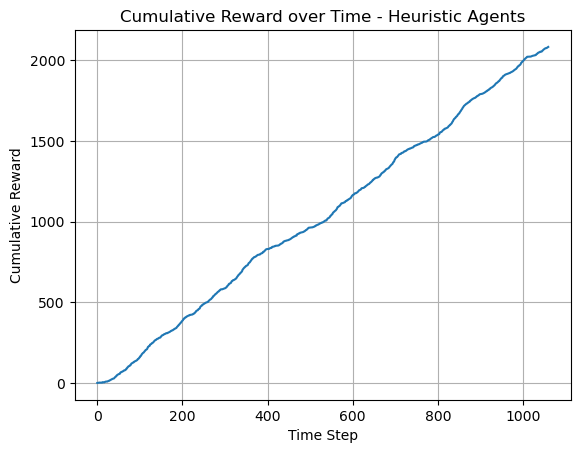

In [14]:
pd.Series(rews).cumsum().plot(title="Cumulative Reward over Time - Heuristic Agents")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Reward")
plt.grid()
plt.show()

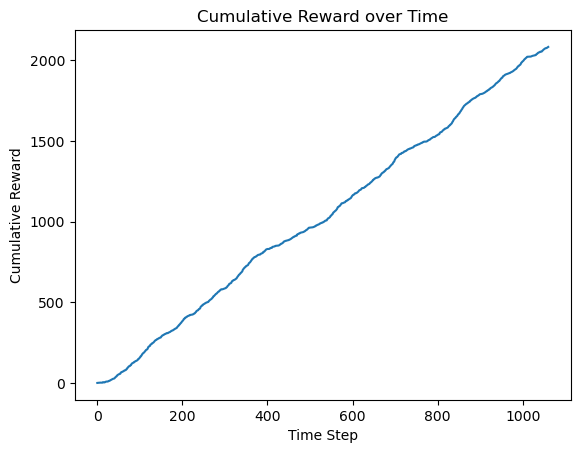

In [15]:
env.breadcrumbs["rewards"].cumsum().plot(title="Cumulative Reward over Time")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Reward")
plt.show()

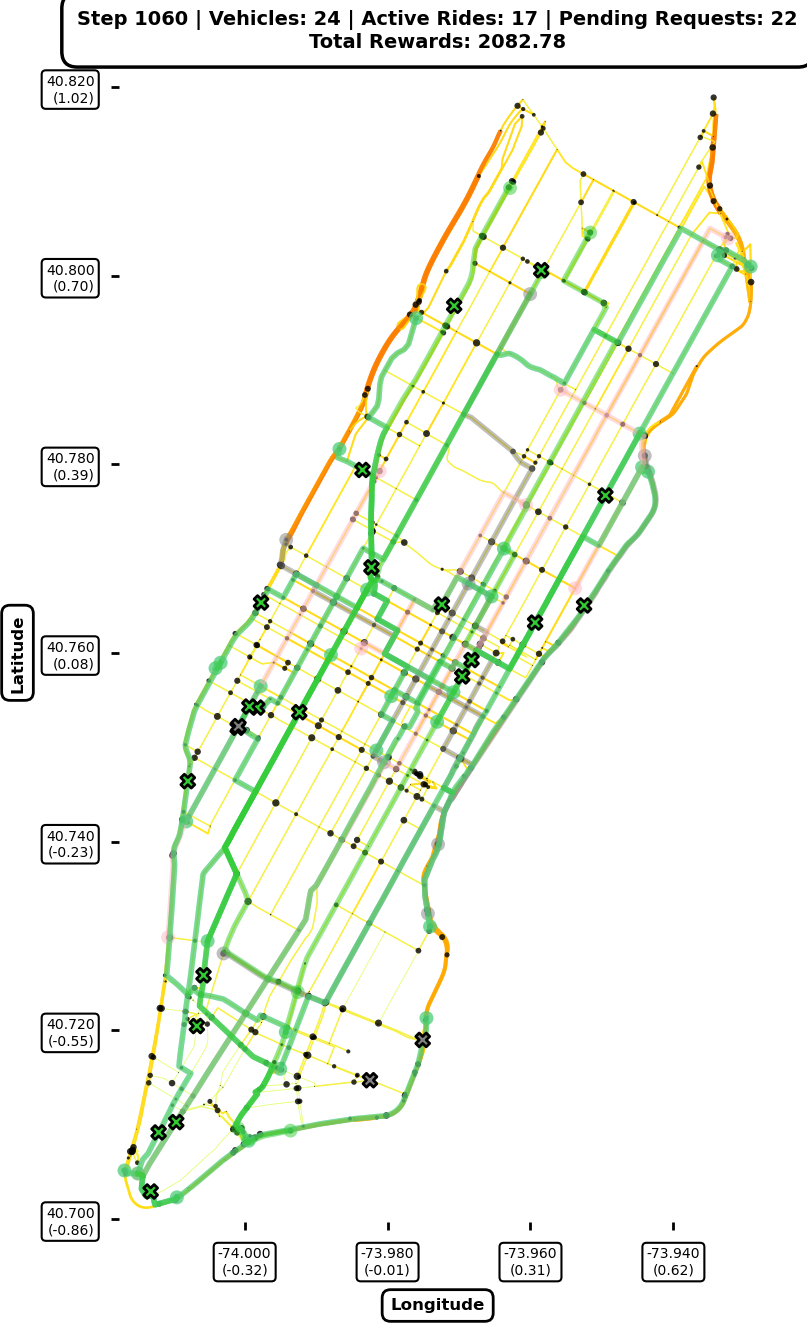

In [16]:
fig, ax = env.render()
fig

<Axes: >

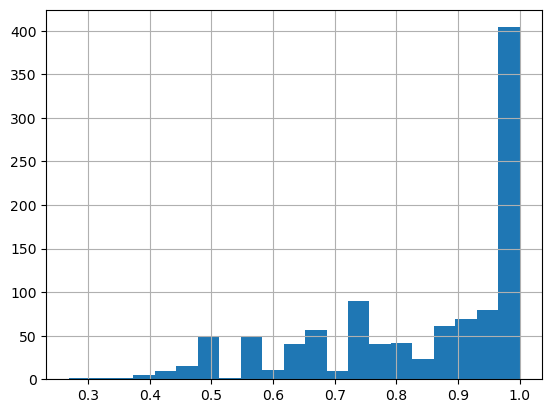

In [17]:
env.breadcrumbs.supply_demand_ratio.hist(bins="rice")

In [18]:
dtt([env.DiscardedRequests])

,request_id,request_dt,cust_id,cust_bias,cust_temperature,est_cost,price,max_wait_time,wait_time,status,pickup_node_id,pickup_x_norm,pickup_y_norm,dropoff_node_id,dropoff_x_norm,dropoff_y_norm,route_nodes,curr_start_node,curr_end_node,route_dist_on_edge,distance_meters,discard_time,discard_step
274,277,2025-01-06 08:31:57.032861,42692,0.804,2.089,2.756,2.969,0 days 00:15:00,0 days 00:07:00,3,42438889,0.107,0.014,42434429,-0.266,0.004,"[42438889, 42438886, 596775867, 596775840, 42434074, 42434072, 42430347, 42430344, 42428297, 42432700, 42432703, 42437368, 42445001, 4491359481, 42444964, 427842070, 42434429]",42438889,42438886,0.0,2756.168,2025-01-06 08:38:57.032861,120
347,330,2025-01-06 08:55:57.032861,24093,2.433,2.486,9.927,13.680,0 days 00:15:00,0 days 00:16:00,-2,42446138,0.472,0.605,42440804,-0.272,-0.601,"[42446138, 42446093, 42446086, 42429324, 42446036, 42435499, 42446021, 42436477, 42445976, 42445972, 42445953, 42445950, 42432825, 42445936, 42436701, 42445928, 42438881, 42434074, 42444043, 42445916, 42445909, 42445908, 42445365, 561042190, 4597668041, 42448693, 42445511, 1918039897, 42430041, 42427327, 42427324, 42427316, 42440804]",42446138,42446093,0.0,9926.524,2025-01-06 09:11:57.032861,153
621,603,2025-01-06 10:51:57.032861,49759,0.300,1.884,11.182,16.778,0 days 00:15:00,0 days 00:16:00,-2,11496014189,-0.254,-0.601,42423203,0.723,0.747,"[11496014189, 42437589, 1773076513, 42429752, 1918039864, 42437612, 1773084402, 42440729, 42448701, 42436586, 42445378, 42449932, 42449685, 11337295608, 42444051, 42434087, 42438891, 42449956, 42436707, 42449963, 42448379, 42432856, 8133385388, 42449971, 4288677093, 6177439759, 42449985, 42447235, 42436486, 42436489, 42443027, 42429340, 42443054, 42443068, 3786728678, 42443116, 42423203]",11496014189,42437589,0.0,11181.900,2025-01-06 11:07:57.032861,269
1810,1829,2025-01-06 19:40:57.032861,39261,-0.695,2.161,4.028,5.116,0 days 00:15:00,0 days 00:01:00,-1,10858288590,-0.398,0.033,4202908174,-0.356,-0.419,"[10858288590, 246650510, 246580797, 42427494, 246580466, 42430589, 42437914, 42437909, 42435624, 42432214, 42430828, 42430237, 4321748237, 4202908174]",10858288590,246650510,0.0,4028.199,2025-01-06 19:41:57.032861,783
2441,2430,2025-01-06 23:44:57.032861,25953,0.157,1.795,4.981,6.584,0 days 00:15:00,0 days 00:15:00,3,42422399,-0.049,0.517,42430589,-0.428,-0.095,"[42422399, 7912855687, 42422592, 42424032, 42431004, 42430745, 42430736, 42430722, 42430704, 42430698, 42430688, 42430685, 7280430895, 42430673, 42430664, 42430646, 42430643, 42430633, 42430607, 246580466, 42430589]",42422399,7912855687,0.0,4980.848,2025-01-06 23:59:57.032861,1041


<Axes: title={'center': 'Discarded Requests by Status'}, xlabel='status'>

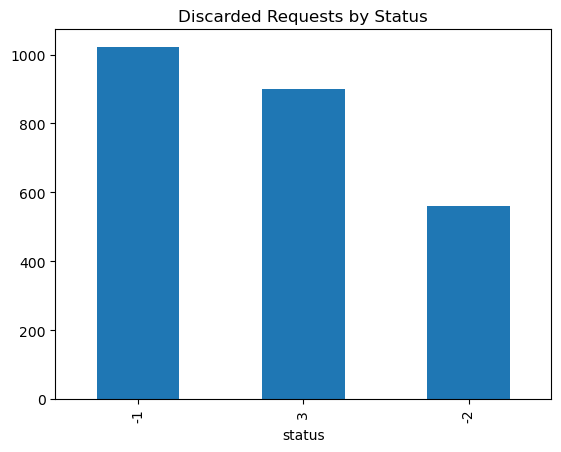

In [19]:
env.DiscardedRequests.status.value_counts().plot(kind="bar", title="Discarded Requests by Status")